# Group Homework 1 — Bayesian Banner CTR

**Course:** Bayesian Statistical Inference

**Format:** Group assignment — one submission per team

Run in [Google Colab](https://colab.research.google.com) or Jupyter Notebook. **Run all cells top to bottom** before submitting.

---

## Business background

A mobile game studio tests a new homepage banner ad.

- Industry CTR benchmarks: **2%–8%**
- CTR = (Total Clicks / Total Impressions) × 100
- Pilot: **200 impressions**, **18 clicks**

Your team will use a **Beta–Binomial** Bayesian model to estimate true CTR, visualize belief updates, compute a **95% credible interval**, and recommend whether to launch site-wide.

## Instructions

Complete **10 tasks** below. Cells marked **YOUR WORK** must be filled in.

| Task | Type | Points (see rubric) |
|------|------|---------------------|
| 1 | Group roster | 5 |
| 2 | Business summary | 5 |
| 3 | Data setup | 5 |
| 4 | Beta prior + justification | 15 |
| 5 | Prior plot | 10 |
| 6 | Binomial likelihood | 10 |
| 7 | Posterior calculation | 15 |
| 8 | Prior vs posterior plot | 10 |
| 9 | 95% credible interval | 15 |
| 10 | Launch recommendation | 10 |

**Rules:** Use Bayesian probability language (not p-values / frequentist confidence intervals). All plots need titles and axis labels.


## Setup — run this cell first


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from IPython.display import display, Markdown

plt.rcParams.update({
    'figure.figsize': (9, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.25,
})

print('Setup complete.')

Setup complete.


---
## Task 1 — Group roster & roles (5 pts)

**YOUR WORK:** Edit the table below. List every teammate and their role on *this* homework (e.g., prior research, coding, plots, report writing, presentation).

| Name | Role on this assignment |
|------|-------------------------|
| 张文雅 | 数据整理与先验设定 |
| 谢镜谦 | 后验计算与代码实现 |
| 李禹佳 | 分布图绘制与结果检查 |
| 孙禹琦 | 业务解释与报告撰写 |


---
## Task 2 — Business problem summary (5 pts)

**YOUR WORK:** In **3–5 sentences**, restate the decision problem. Include: what CTR measures, the pilot data, the 2%–8% benchmark, and why Bayesian updating is appropriate before a full launch.

> 点击率（CTR）是点击次数除以广告展示次数，用来衡量看到横幅的用户中有多少人点击。此次试点获得18次点击、200次展示，样本点击率为9%；行业历史基准通常为2%至8%。在全站推广之前，试点样本仍有限，真实点击率存在不确定性。贝叶斯更新可以把行业基准所表达的先验信念与本次试点数据结合，得到真实点击率的后验分布及可信区间，从而支持更审慎的上线决策。


---
## Task 3 — Observed data setup (5 pts)

Define the pilot test sample size and click count in code.


In [2]:
# YOUR WORK: set the correct values from the assignment brief
n_impressions = 200  # 总展示次数
n_clicks = 18        # 总点击次数

# Sample CTR (point estimate — not our final answer)
sample_ctr = n_clicks / n_impressions

display(Markdown(
    f"Pilot: **{n_clicks}** clicks out of **{n_impressions}** impressions → sample CTR = **{sample_ctr:.1%}**"
))

Pilot: **18** clicks out of **200** impressions → sample CTR = **9.0%**

---
## Task 4 — Beta prior selection & justification (15 pts)

Model unknown true CTR $\theta$ with $\theta \sim \text{Beta}(\alpha, \beta)$ **before** seeing the pilot.

**YOUR WORK (code):** Choose `alpha_prior` and `beta_prior` so your prior beliefs align with the **2%–8%** industry range.

**YOUR WORK (markdown below this section):** Explain *why* you picked those hyperparameters (prior mean, spread, and link to the benchmark).


In [3]:
# YOUR WORK: choose hyperparameters
alpha_prior = 5
beta_prior = 95

prior = stats.beta(alpha_prior, beta_prior)
prior_mean = prior.mean()
prior_sd = prior.std()

display(Markdown(
    f"Prior: Beta({alpha_prior}, {beta_prior}) → mean = **{prior_mean:.2%}**, sd = **{prior_sd:.3f}**"
))

Prior: Beta(5, 95) → mean = **5.00%**, sd = **0.022**

**Task 4 — Written justification (replace with your answer):**

> Beta(5, 95) 的先验均值为5%，位于2%–8%行业基准的中间。先验参数之和为100，代表相对温和的先验信息；先验标准差约为2.17个百分点，因此并未把真实点击率预先固定在单一值。该先验的大部分概率质量落在2%–8%范围内，与历史基准相符。α=5和β=95分别对应先验中的点击与未点击伪计数，后续会与试点观察到的点击和未点击次数相加。


---
## Task 5 — Prior PDF plot (10 pts)

Plot the **prior** density over $\theta \in [0, 1]$ (or a focused range such as 0 to 0.15 for CTR).


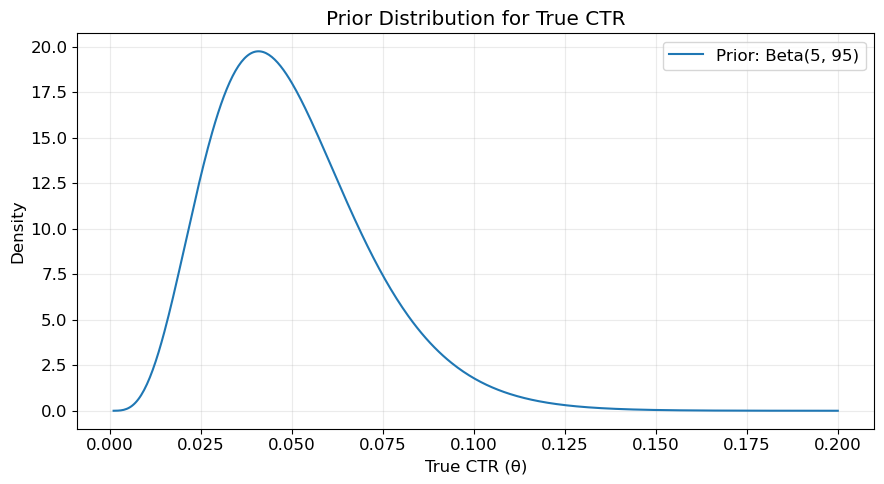

In [4]:
# YOUR WORK: complete the plot (add title, x/y labels, legend if needed)
theta = np.linspace(0.001, 0.20, 500)

fig, ax = plt.subplots()

ax.plot(theta, prior.pdf(theta), label='Prior: Beta(5, 95)', color='tab:blue')
ax.legend()

ax.set_xlabel('True CTR (θ)')
ax.set_ylabel('Density')
ax.set_title('Prior Distribution for True CTR')
plt.tight_layout()
plt.show()

---
## Task 6 — Binomial likelihood (10 pts)

Given $\theta$, pilot clicks follow $\text{Binomial}(n, \theta)$. Implement the likelihood (or log-likelihood) for the observed data.

**YOUR WORK:** Complete the function and one-line comment on what the likelihood represents.


In [6]:
def binomial_log_likelihood(theta, n, k):
    """Log-likelihood of observing k clicks in n impressions."""
    # 似然衡量不同真实点击率对当前试点观测结果的支持程度。
    return stats.binom.logpmf(k, n, theta)


# Quick check at sample CTR (optional sanity check)
print(binomial_log_likelihood(sample_ctr, n_impressions, n_clicks))

-2.321639434844343


> 似然表示在给定真实点击率 θ 时，观察到200次展示中18次点击的相对支持程度。它不是 θ 本身的概率；点击率越能解释当前观测结果，其对应的似然通常越高。


---
## Task 7 — Posterior calculation (15 pts)

With a Beta prior and Binomial likelihood, the posterior is conjugate:

$$\theta \mid \text{data} \sim \text{Beta}(\alpha + k,\; \beta + n - k)$$

**YOUR WORK:** Compute posterior hyperparameters and posterior mean.


In [7]:
# YOUR WORK: conjugate posterior
alpha_post = alpha_prior + n_clicks
beta_post = beta_prior + n_impressions - n_clicks

posterior = stats.beta(alpha_post, beta_post)
post_mean = posterior.mean()

display(Markdown(
    f"Posterior: Beta({alpha_post}, {beta_post}) → mean CTR = **{post_mean:.2%}**"
))

Posterior: Beta(23, 277) → mean CTR = **7.67%**

---
## Task 8 — Prior vs posterior plot (10 pts)

Overlay **prior** and **posterior** PDFs on one figure to show how the pilot data shifted beliefs.


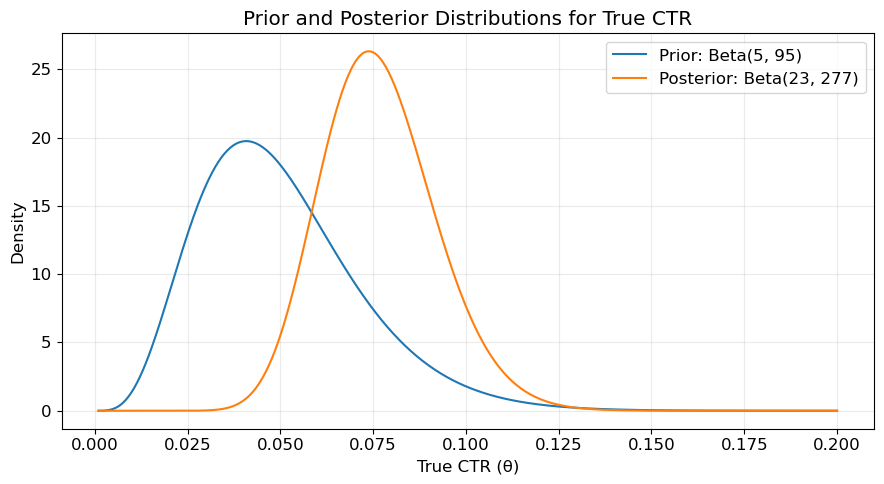

In [8]:
fig, ax = plt.subplots()

ax.plot(theta, prior.pdf(theta), label='Prior: Beta(5, 95)', color='tab:blue')
ax.plot(theta, posterior.pdf(theta), label=f'Posterior: Beta({alpha_post}, {beta_post})', color='tab:orange')

ax.set_xlabel('True CTR (θ)')
ax.set_ylabel('Density')
ax.set_title('Prior and Posterior Distributions for True CTR')
ax.legend()
plt.tight_layout()
plt.show()

---
## Task 9 — 95% credible interval & business translation (15 pts)

Compute the **95% posterior credible interval** for $\theta$ and interpret it for a non-technical stakeholder.

Use Bayesian wording: e.g., *"Given the pilot data, there is a 95% probability the true CTR lies between …"*

**Do not** call this a "95% confidence interval."


In [9]:
# YOUR WORK: 95% credible interval from the POSTERIOR
ci_low, ci_high = posterior.ppf([0.025, 0.975])

display(Markdown(
    f"**95% credible interval:** [{ci_low:.2%}, {ci_high:.2%}]"
))

**95% credible interval:** [4.94%, 10.93%]

**Task 9 — Business translation (2–3 sentences, YOUR WORK):**

> 根据试点数据，真实点击率有95%的后验概率落在上方可信区间内。这个范围同时包含低于和高于行业基准上限8%的可能性，说明目前仍无法确定全站推广后会达到哪种表现。


---
## Task 10 — Launch recommendation (10 pts)

**YOUR WORK:** Recommend one of: **Roll out site-wide** / **Do not roll out** / **Run a larger pilot first**.

Support your answer using **only** Bayesian results (posterior mean, credible interval, prior–posterior shift). Discuss a business tradeoff in **3–5 sentences**.

> **建议：先扩大试点，再决定是否全站推广。**后验均值由先验的5.00%上移至约7.67%，说明试点数据提高了我们对较高点击率的信念。后验95%可信区间约为4.9%–10.9%，仍覆盖行业基准上限8%的两侧，当前不确定性尚不足以支持无条件全量推广。增加试点样本有机会收窄后验可信区间、降低判断不确定性的代价是延后扩量；相比之下，这能减少真实点击率偏低时过早投入全站流量的业务风险。


---
## Submission checklist

Before you submit, confirm:

- [ ] All **10 tasks** completed; no `NotImplementedError` or `None` left in code
- [ ] **Run all cells** — notebook runs without errors
- [ ] Every plot has **title** and **axis labels**
- [ ] PDF report includes: roles, prior justification, figures, credible interval, conclusion
- [ ] PDF includes **Colab link** or code appendix
- [ ] Language is **Bayesian** (credible interval / posterior probability), not frequentist

**Grading rubric:** see `6000_group_homework_01_rubric.md` in the same folder (instructor use).
